Realizado por:

Sergio Alonso Zarcero,
Andrea Pascual Aguilera,
Ángel Meda López,
Marta Pulido Alobera y
Sandra Zorrilla Gutiérrez.


**Para ir ejecutando el código es necesario ir pulsando secuencialmente el botón de Play (Ejecutar) para cada bloque de código, ubicado ne la esquina superior izquierda del mismo.**

Paso 1: Importar las librerías necesarias y definir las acciones

In [ ]:
import pandas as pd   #para manipular datos
import numpy as np    #para cálculos numéricos
import yfinance as yf   #para descargar datos financieros de Yahoo Finance
import matplotlib.pyplot as plt   #para optimización numérica
from scipy.optimize import minimize

# Definir las seis acciones seleccionadas del IBEX-35
acciones = ['AENA.MC', 'BBVA.MC', 'SAN.MC', 'IBE.MC', 'ANA.MC', 'TEF.MC']
fecha_inicio = '2024-01-02'
fecha_fin = '2024-10-31'

np.set_printoptions(precision=6, suppress=True)

pd.set_option('display.float_format', '{:.6f}'.format)

# Mostrar todas las filas
pd.set_option('display.max_rows', None)

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Aumentar el ancho máximo de las celdas
pd.set_option('display.max_colwidth', None)

# Aumentar el ancho de salida para columnas largas
pd.set_option('display.width', 1000)




Paso 2: Descargar los datos de precios y dividendos

In [ ]:

data = yf.download(acciones, start=fecha_inicio, end=fecha_fin, actions=True)

#usamos actions=True para que descargue tambien los dividendos

precios_cierre = data['Adj Close']
dividendos = data['Dividends']
#pd.reset_option('all')

print("Precios de cierre:")
print(precios_cierre)
print("")
print("Dividendos:")
print(dividendos)


[*********************100%***********************]  6 of 6 completed


Precios de cierre:
Ticker        AENA.MC     ANA.MC   BBVA.MC    IBE.MC   SAN.MC   TEF.MC
Date                                                                  
2024-01-02 157.231735 126.002632  7.883204 11.341313 3.693940 3.496931
2024-01-03 153.018463 121.697304  7.784032 11.303111 3.642176 3.509461
2024-01-04 155.172974 122.510536  7.915013 11.489347 3.719343 3.564402
2024-01-05 154.359039 121.266777  7.965535 11.494122 3.750497 3.560546
2024-01-08 154.885712 120.357872  8.047866 11.455920 3.766793 3.597174
2024-01-09 157.279617 121.745148  7.871976 11.307294 3.730366 3.595246
2024-01-10 158.955353 123.036751  7.860750 11.273293 3.689626 3.575968
2024-01-11 159.529892 122.462700  7.746608 11.190723 3.635945 3.589463
2024-01-12 161.684402 125.045891  7.754094 11.341293 3.644093 3.584643
2024-01-15 161.636520 122.223518  7.720412 11.331578 3.604311 3.635728
2024-01-16 159.290497 117.296303  7.617499 11.219866 3.560695 3.638620
2024-01-17 154.885712 111.699379  7.572591 11.122724 3.512

Paso 3: Calcular los rendimientos diarios

In [ ]:
rendimientos_diarios = ((dividendos + precios_cierre - precios_cierre.shift(1)) / precios_cierre.shift(1)).dropna()

print("Rendimientos diarios:")
print(rendimientos_diarios)

#Calculamos los rendimientos diarios de cada acción como el cambio porcentual entre precios de cierre. La función dropna() elimina los valores NaN en la primera fila (debido a la diferencia inicial).

Rendimientos diarios:
Ticker       AENA.MC    ANA.MC   BBVA.MC    IBE.MC    SAN.MC    TEF.MC
Date                                                                  
2024-01-03 -0.026797 -0.034169 -0.012580 -0.003368 -0.014013  0.003583
2024-01-04  0.014080  0.006682  0.016827  0.016477  0.021187  0.015655
2024-01-05 -0.005245 -0.010152  0.006383  0.000416  0.008376 -0.001082
2024-01-08  0.003412 -0.007495  0.010336 -0.003324  0.004345  0.010287
2024-01-09  0.015456  0.011526 -0.021855  0.004659 -0.009670 -0.000536
2024-01-10  0.010654  0.010609 -0.001426 -0.003007 -0.010921 -0.005362
2024-01-11  0.003614 -0.004666 -0.014520 -0.007324 -0.014549  0.003774
2024-01-12  0.013505  0.021094  0.000966  0.013455  0.002241 -0.001343
2024-01-15 -0.000296 -0.022571 -0.004344 -0.000857 -0.010917  0.014251
2024-01-16 -0.014514 -0.040313 -0.013330 -0.009859 -0.012101  0.000795
2024-01-17 -0.027653 -0.047716 -0.005895 -0.008658 -0.013461 -0.001060
2024-01-18  0.011437  0.003854 -0.001236 -0.016157  0.0

Rendimientos esperados de cada accion:

In [ ]:
# Crear un diccionario para almacenar los rendimientos esperados
rendimientos_esperados = {}

# Calcular el rendimiento esperado (promedio de los retornos diarios) para cada acción usando un for
for accion in acciones:
    rendimientos_esperados[accion] = rendimientos_diarios[accion].mean()

# Mostrar los rendimientos esperados
print(rendimientos_esperados)

{'AENA.MC': 0.0015150501401280576, 'BBVA.MC': 0.0011427714604438797, 'SAN.MC': 0.0011559521088695488, 'IBE.MC': 0.0011754575997908047, 'ANA.MC': 0.00018155624324068905, 'TEF.MC': 0.0012317009596614311}


Paso 4: Graficar el histograma de los rendimientos diarios

In [ ]:
'''Para cada acción, generamos un histograma de sus rendimientos diarios.
	•	plt.hist() dibuja el histograma.
	•	bins=30 especifica el número de barras.
	•	alpha=0.7 ajusta la transparencia.
	•	plt.show() muestra cada gráfico individualmente.
  '''

import matplotlib.pyplot as plt
import seaborn as sns

# Crear una figura con subgráficos: uno por acción
fig, axes = plt.subplots(len(rendimientos_diarios.columns), 1, figsize=(8, 4 * len(rendimientos_diarios.columns)))
fig.tight_layout(pad=5.0)

# Iterar sobre cada acción y su correspondiente subgráfico
for i, accion in enumerate(rendimientos_diarios.columns):
    ax = axes[i]
    # Histograma normalizado
    ax.hist(
        rendimientos_diarios[accion],
        bins=30,
        alpha=0.4,  # Transparencia
        #label=f'Histograma',
        density=True
    )
    # Curva de densidad
    sns.kdeplot(
        rendimientos_diarios[accion],
        label=f'Curva de densidad',
        ax=ax
    )
    # Configuración del subgráfico
    ax.set_title(f'Histograma y Densidad de {accion}')
    ax.set_xlabel('Rendimiento')
    ax.set_ylabel('Densidad')
    ax.legend()

# Mostrar la figura con todos los subgráficos
plt.show()

Mostrar matriz de covarianzas

In [ ]:
# Calcular matriz de covarianza de los rendimientos
matriz_cov = rendimientos_diarios.cov()

print("Matriz de covarianza:")
print(matriz_cov)

Matriz de covarianza:
Ticker   AENA.MC   ANA.MC  BBVA.MC   IBE.MC   SAN.MC   TEF.MC
Ticker                                                       
AENA.MC 0.000139 0.000062 0.000074 0.000023 0.000050 0.000026
ANA.MC  0.000062 0.000365 0.000072 0.000116 0.000078 0.000062
BBVA.MC 0.000074 0.000072 0.000307 0.000031 0.000194 0.000038
IBE.MC  0.000023 0.000116 0.000031 0.000094 0.000037 0.000033
SAN.MC  0.000050 0.000078 0.000194 0.000037 0.000246 0.000044
TEF.MC  0.000026 0.000062 0.000038 0.000033 0.000044 0.000089


Matriz de correlaciones

In [ ]:
# Calcular la matriz de correlaciones de los rendimientos diarios
matriz_correlaciones = rendimientos_diarios.corr()

# Mostrar la matriz de correlaciones
print(matriz_correlaciones)

Ticker   AENA.MC   ANA.MC  BBVA.MC   IBE.MC   SAN.MC   TEF.MC
Ticker                                                       
AENA.MC 1.000000 0.274417 0.358438 0.203826 0.270693 0.229454
ANA.MC  0.274417 1.000000 0.215690 0.622966 0.261575 0.342414
BBVA.MC 0.358438 0.215690 1.000000 0.182065 0.704049 0.230494
IBE.MC  0.203826 0.622966 0.182065 1.000000 0.243826 0.358917
SAN.MC  0.270693 0.261575 0.704049 0.243826 1.000000 0.300511
TEF.MC  0.229454 0.342414 0.230494 0.358917 0.300511 1.000000


In [ ]:
def construir_matrizA(matriz, rendimientos_esperados):
    """
    Construye la matriz A para un número dinámico de acciones basado en la matriz de covarianzas.

    Args:
    - matriz (pd.DataFrame): Matriz de covarianzas.
    - rendimientos_esperados (dict): Rendimientos esperados por activo.

    Returns:
    - pd.DataFrame: Matriz extendida con restricciones.
    """
    # Duplicar los valores de la matriz (para aplicar la condición del lagrangiano)
    m = matriz * 2

    # Crear la fila extra con los rendimientos esperados negativos
    E_values = [-1 * rendimientos_esperados[accion] for accion in m.index]
    m['extraX1'] = E_values  # Añadir columna extra con los rendimientos negativos

    # Crear una fila de -1 dinámicamente según el número de activos
    num_activos = matriz.shape[0]
    m['extraX2'] = [-1] * num_activos  # Segunda columna extra de -1

    # Añadir dos filas extras: una con rendimientos esperados y otra con -1
    fila_extra1 = E_values + [0, 0]  # Rendimientos esperados negativos con dos ceros extra
    fila_extra2 = [-1] * num_activos + [0, 0]  # Fila completa de -1 con ceros extra

    m.loc['extraY1'] = fila_extra1
    m.loc['extraY2'] = fila_extra2

    return m


matrizA = construir_matrizA(matriz_cov, rendimientos_esperados)
print(matrizA)


Ticker    AENA.MC    ANA.MC   BBVA.MC    IBE.MC    SAN.MC    TEF.MC   extraX1   extraX2
Ticker                                                                                 
AENA.MC  0.000278  0.000124  0.000148  0.000047  0.000100  0.000051 -0.001515 -1.000000
ANA.MC   0.000124  0.000730  0.000144  0.000231  0.000157  0.000123 -0.000182 -1.000000
BBVA.MC  0.000148  0.000144  0.000614  0.000062  0.000387  0.000076 -0.001143 -1.000000
IBE.MC   0.000047  0.000231  0.000062  0.000188  0.000074  0.000066 -0.001175 -1.000000
SAN.MC   0.000100  0.000157  0.000387  0.000074  0.000493  0.000089 -0.001156 -1.000000
TEF.MC   0.000051  0.000123  0.000076  0.000066  0.000089  0.000178 -0.001232 -1.000000
extraY1 -0.001515 -0.000182 -0.001143 -0.001175 -0.001156 -0.001232  0.000000  0.000000
extraY2 -1.000000 -1.000000 -1.000000 -1.000000 -1.000000 -1.000000  0.000000  0.000000


In [ ]:
def construir_inv_matrizA(m):
  return pd.DataFrame(np.linalg.inv(m), columns=m.columns, index=m.index)

inv_matrizA = construir_inv_matrizA(matrizA)
print(inv_matrizA)

Ticker       AENA.MC      ANA.MC      BBVA.MC       IBE.MC       SAN.MC       TEF.MC     extraX1   extraX2
Ticker                                                                                                    
AENA.MC  3075.790605  998.452772  -764.179236 -1888.639735   -37.183282 -1384.241125 -511.794527  0.479010
ANA.MC    998.452772  345.560319  -324.494860  -816.793421   -68.404932  -134.319879  830.717883 -1.037922
BBVA.MC  -764.179236 -324.494860  3385.898245   257.425807 -2526.058299   -28.591658  141.752284 -0.208698
IBE.MC  -1888.639735 -816.793421   257.425807  6160.452969  -617.407178 -3095.038442 -504.497194  0.243689
SAN.MC    -37.183282  -68.404932 -2526.058299  -617.407178  4233.243620  -984.189929  -21.413546 -0.015208
TEF.MC  -1384.241125 -134.319879   -28.591658 -3095.038442  -984.189929  5626.381032   65.235100 -0.460871
extraY1  -511.794527  830.717883   141.752284  -504.497194   -21.413546    65.235100 -369.518251  0.518810
extraY2     0.479010   -1.037922    -

In [ ]:
def construir_matrizB(E, matriz):
    """
    Construye la matriz B para un número dinámico de acciones.

    Args:
    - E (float): Rendimiento esperado deseado.

    Returns:
    - pd.DataFrame: Matriz B.
    """
    # Obtener el número de activos (columnas) de la matriz
    num_activos = len(matriz.columns)

    # Crear la parte de ceros (número de ceros igual al número de activos)
    ceros = np.zeros((num_activos, 1))  # número de ceros igual al número de activos

    # Crear la fila final con [-E, -1]
    data = np.vstack([ceros, np.array([[-E], [-1]])])  # Añadir la fila con -E y -1

    # Crear un DataFrame
    m = pd.DataFrame(data, columns=['Valores'])

    return m


In [ ]:
def calcular_matrizX(E, covarianzas, rendimientos):
  print(f"\nPara E = {E}, las matrices son:")
  matrizA = construir_matrizA(covarianzas, rendimientos)
  print(f"Matriz A:\n{matrizA}")
  inv_matrizA = construir_inv_matrizA(matrizA)
  print(f"Matriz A inversa:\n{inv_matrizA}")
  matrizB = construir_matrizB(E, covarianzas)
  print(f"Matriz B:\n{matrizB}")
  print(f"Matriz X:\n{np.dot(inv_matrizA, matrizB)}")
  return np.dot(inv_matrizA, matrizB)







In [ ]:
def calcular_cartera_men_var(E, covarianzas, rendimientos):
    """
    Calcula las proporciones óptimas de la cartera, varianza, volatilidad y rendimiento esperado.

    Args:
    - E (float): Retorno esperado deseado de la cartera.
    - covarianzas (pd.DataFrame): Matriz de varianzas y covarianzas de los activos.
    - rendimientos (dict): Rendimientos esperados de los activos.

    Returns:
    - dict: Un diccionario con las proporciones, rendimiento, varianza y volatilidad de la cartera.
    """
    # Resolver el sistema para obtener las proporciones y multiplicadores de Lagrange
    X = calcular_matrizX(E, covarianzas, rendimientos)
    # Obtener proporciones como un pd.Series con los índices de la matriz de covarianzas
    proportions = pd.Series(X[:len(covarianzas), 0], index=covarianzas.columns)
    lambda1, lambda2 = X[len(covarianzas), 0], X[len(covarianzas)+1, 0]
    # Rendimiento esperado de la cartera
    rendimiento_cartera = sum(proportions[ticker] * rendimientos[ticker] for ticker in rendimientos)
    # Cálculo de la varianza de la cartera
    varianza_cartera = proportions.T @ covarianzas @ proportions
    # Volatilidad (desviación estándar)
    volatilidad_cartera = varianza_cartera**0.5
    # Mostrar resultados
    print("Proporciones óptimas de los activos:")
    print(proportions)
    print(f"Rendimiento esperado de la cartera: {rendimiento_cartera}")
    print(f"Varianza de la cartera: {varianza_cartera}")
    print(f"Volatilidad (desviación estándar) de la cartera: {volatilidad_cartera}")
    print(f"Multiplicador de Lagrange asociado al rendimiento esperado: {lambda1}")
    print(f"Multiplicador de Lagrange asociado a la suma de proporciones: {lambda2}")
    print(f"Suma de proporciones: {proportions.sum()}")

    # Retornar las coordenadas
    return volatilidad_cartera, rendimiento_cartera










Cálculo de las esperanzas de nuestras carteras

In [ ]:
def calcular_Eps(rendimientos, n):
    """
    Calcula e imprime la acción con el rendimiento más bajo y más alto.
    Args:
    - rendimientos (dict): Diccionario con clave como el nombre de la acción y valor como su rendimiento.
    Returns:
    - menor (str, float): Acción y rendimiento con el menor valor.
    - mayor (str, float): Acción y rendimiento con el mayor valor.
    """
    # Encontrar el rendimiento más bajo (menor) y más alto (mayor)
    menor = min(rendimientos.items(), key=lambda x: x[1])
    mayor = max(rendimientos.items(), key=lambda x: x[1])
    # Imprimir los resultados
    print(f"La acción con el menor rendimiento es {menor[0]} con un valor de {menor[1]:.4f}")
    print(f"La acción con el mayor rendimiento es {mayor[0]} con un valor de {mayor[1]:.4f}")
    diferencia = mayor[1] - menor[1]
    print(f"La diferencia entre el mayor y el menor rendimiento es de {diferencia:.4f}")
    E_carteras = []
    intervalo = diferencia/(n-1)
    for i in range(n):
      E_carteras.append((menor[1] + intervalo * (i))*2)
    return E_carteras

E_carteras = calcular_Eps(rendimientos_esperados, 9)
print(E_carteras)


La acción con el menor rendimiento es ANA.MC con un valor de 0.0002
La acción con el mayor rendimiento es AENA.MC con un valor de 0.0015
La diferencia entre el mayor y el menor rendimiento es de 0.0013
[0.0003631124864813781, 0.0006964859607032203, 0.0010298594349250623, 0.0013632329091469045, 0.0016966063833687465, 0.0020299798575905887, 0.002363353331812431, 0.002696726806034273, 0.003030100280256115]


Se calculan todas las carteras con las esperanzas anteriores y obtenemos sus coordenadas para dibujar la frontera eficiente.

In [ ]:
coordenadas = []



def todas_carteras_men_varianza (covarianzas, rendimientos, numero, coordenadas, E):
  Eps = calcular_Eps(rendimientos, numero)

  print(f"Se usarán las siguientes esperanzas para cada cartera, respectivamente: {Eps}")
  for E in Eps:
    cartera = calcular_cartera_men_var(E, covarianzas, rendimientos)
    coordenadas.append([cartera[0], cartera[1]])
  return coordenadas

todas_carteras_men_varianza(matriz_cov, rendimientos_esperados, 9, coordenadas, E_carteras)





La acción con el menor rendimiento es ANA.MC con un valor de 0.0002
La acción con el mayor rendimiento es AENA.MC con un valor de 0.0015
La diferencia entre el mayor y el menor rendimiento es de 0.0013
Se usarán las siguientes esperanzas para cada cartera, respectivamente: [0.0003631124864813781, 0.0006964859607032203, 0.0010298594349250623, 0.0013632329091469045, 0.0016966063833687465, 0.0020299798575905887, 0.002363353331812431, 0.002696726806034273, 0.003030100280256115]

Para E = 0.0003631124864813781, las matrices son:
Matriz A:
Ticker    AENA.MC    ANA.MC   BBVA.MC    IBE.MC    SAN.MC    TEF.MC   extraX1   extraX2
Ticker                                                                                 
AENA.MC  0.000278  0.000124  0.000148  0.000047  0.000100  0.000051 -0.001515 -1.000000
ANA.MC   0.000124  0.000730  0.000144  0.000231  0.000157  0.000123 -0.000182 -1.000000
BBVA.MC  0.000148  0.000144  0.000614  0.000062  0.000387  0.000076 -0.001143 -1.000000
IBE.MC   0.000047  0

[[0.01577384260593714, 0.0003631124864813781],
 [0.011879456307484593, 0.0006964859607032203],
 [0.008631125149315475, 0.0010298594349250623],
 [0.006995614919505612, 0.0013632329091469043],
 [0.00802797623551701, 0.0016966063833687463],
 [0.01100116559057244, 0.002029979857590589],
 [0.014787506681030353, 0.0023633533318124307],
 [0.018904563758759214, 0.0026967268060342736],
 [0.023176759384211158, 0.0030301002802561156]]

Dibujamos la frontera eficiente con las coordenadas obtenidas

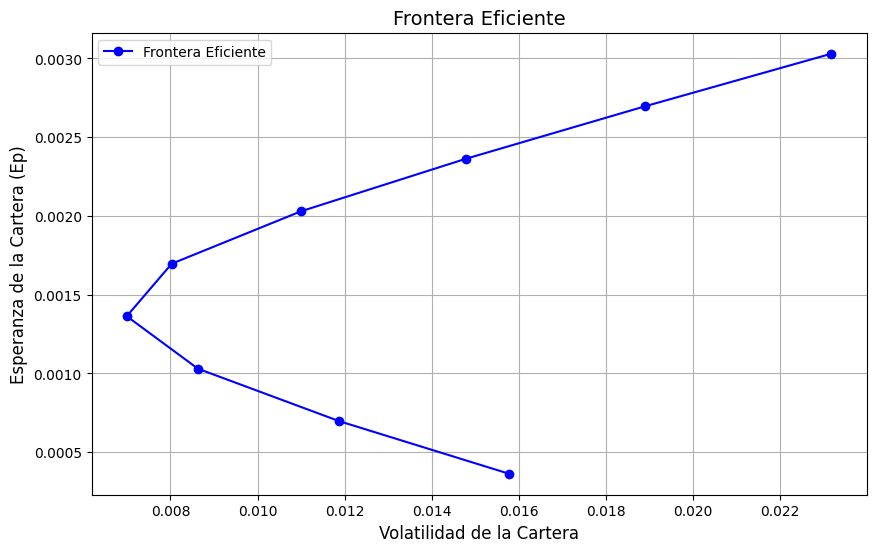

In [ ]:

# Separar las coordenadas en dos listas: volatilidad (x) y esperanza (y)
volatilidad = [coord[0] for coord in coordenadas]
esperanza = [coord[1] for coord in coordenadas]

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(volatilidad, esperanza, marker='o', linestyle='-', color='blue', label="Frontera Eficiente")

# Etiquetas de los ejes
plt.xlabel("Volatilidad de la Cartera", fontsize=12)
plt.ylabel("Esperanza de la Cartera (Ep)", fontsize=12)

# Títulos y leyendas
plt.title("Frontera Eficiente", fontsize=14)
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()

Cálculo de la cartera de varianza mínima

In [ ]:
def construir_matrizA2(matriz):

    num_activos = matriz.shape[0]

    # Duplicar los valores de la matriz (para aplicar la condición del lagrangiano)
    m = matriz * 2

    m['extraX1'] = [-1] * num_activos

    m.loc['extraY1'] = [-1] * num_activos + [0]

    return m





def construir_matrizB2(matriz):
      # Obtener el número de activos (columnas) de la matriz
    num_activos = len(matriz.columns) if isinstance(matriz, pd.DataFrame) else len(matriz[0])

    # Crear la matriz B2 con 0s repetidos y un -1 al final
    matriz_B2 = np.zeros((num_activos + 1, 1))
    matriz_B2[-1, 0] = -1  # Asignar -1 al último valor

    # Devolver la matriz como un DataFrame
    return pd.DataFrame(matriz_B2, columns=['B2'])


def calcular_matrizX2(covarianzas):
  matrizA2 = construir_matrizA2(covarianzas)
  inv_matrizA2 = construir_inv_matrizA(matrizA2)
  matrizB2 = construir_matrizB2(covarianzas)
  return np.dot(inv_matrizA2, matrizB2)


print (calcular_matrizX2(matriz_cov))


[[ 0.239558]
 [-0.128419]
 [ 0.009676]
 [ 0.464633]
 [ 0.045273]
 [ 0.36928 ]
 [ 0.000097]]


In [ ]:
def calc_cart_minim_var(covarianzas, rendimientos):

    # Resolver el sistema para obtener las proporciones y multiplicadores de Lagrange
    X = calcular_matrizX2(covarianzas)

    # Obtener proporciones como un pd.Series con los índices de la matriz de covarianzas
    proportions = pd.Series(X[:len(covarianzas), 0], index=covarianzas.columns)
    lambda1 = X[len(covarianzas), 0]

    # Rendimiento esperado de la cartera
    rendimiento_cartera = sum(proportions[ticker] * rendimientos[ticker] for ticker in rendimientos)

    # Cálculo de la varianza de la cartera

    varianza_cartera = proportions.T @ covarianzas @ proportions



    # Volatilidad (desviación estándar)
    volatilidad_cartera = varianza_cartera**0.5

    # Mostrar resultados
    print("Proporciones óptimas de los activos:")
    print(proportions)
    print(f"Rendimiento esperado de la cartera: {rendimiento_cartera}")
    print(f"Varianza de la cartera: {varianza_cartera}")
    print(f"Volatilidad (desviación estándar) de la cartera: {volatilidad_cartera}")
    print(f"Multiplicador de Lagrange asociado a la suma de proporciones: {lambda1}")
    print(f"Suma de proporciones: {proportions.sum()}")

    # Retornar las coordenadas
    return volatilidad_cartera, rendimiento_cartera

coordenadas2 = coordenadas.copy()



coor_cart_min_var = calc_cart_minim_var(matriz_cov, rendimientos_esperados)

coordenadas2.append([coor_cart_min_var[0], coor_cart_min_var[1]])


Proporciones óptimas de los activos:
Ticker
AENA.MC    0.239558
ANA.MC    -0.128419
BBVA.MC    0.009676
IBE.MC     0.464633
SAN.MC     0.045273
TEF.MC     0.369280
dtype: float64
Rendimiento esperado de la cartera: 0.00140401593357432
Varianza de la cartera: 4.863132718211336e-05
Volatilidad (desviación estándar) de la cartera: 0.006973616506670937
Multiplicador de Lagrange asociado a la suma de proporciones: 9.726265436422674e-05
Suma de proporciones: 1.0


In [ ]:
print(coordenadas)
print(coordenadas2)




[[0.015773843608401783, 0.00036311248648137793], [0.011879456991530932, 0.00069648596070322], [0.008631125492375909, 0.0010298594349250623], [0.006995614964879221, 0.0013632329091469045], [0.008027976259851273, 0.0016966063833687463], [0.011001165826439577, 0.002029979857590589], [0.01478750718928316, 0.002363353331812431], [0.018904564550012062, 0.002696726806034273], [0.02317676045952577, 0.003030100280256116]]
[[0.015773843608401783, 0.00036311248648137793], [0.011879456991530932, 0.00069648596070322], [0.008631125492375909, 0.0010298594349250623], [0.006995614964879221, 0.0013632329091469045], [0.008027976259851273, 0.0016966063833687463], [0.011001165826439577, 0.002029979857590589], [0.01478750718928316, 0.002363353331812431], [0.018904564550012062, 0.002696726806034273], [0.02317676045952577, 0.003030100280256116], [0.006973616506670937, 0.00140401593357432]]


Representamos la cartera de mínima varianza en la frontera eficiente

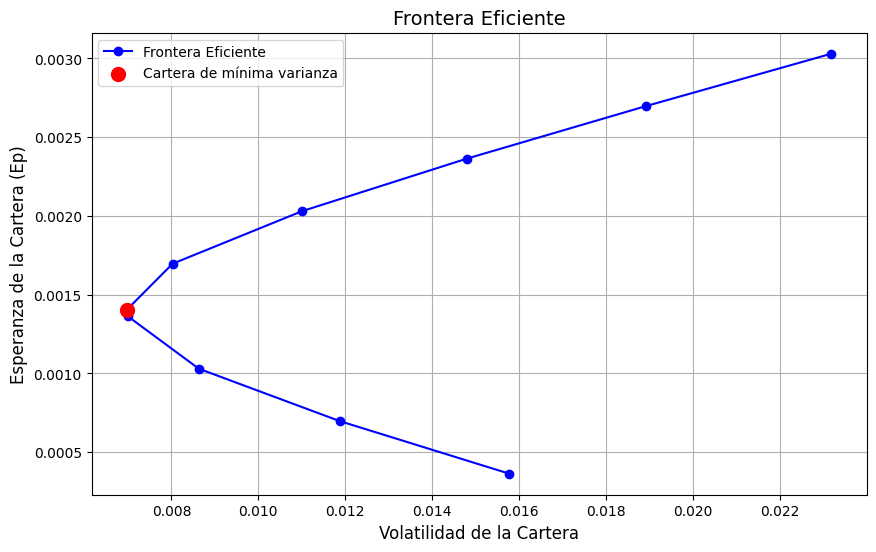

In [ ]:
coordenadas2copy = coordenadas2.copy()

# Guardar la última coordenada antes de ordenar
ultima_coordenada = coordenadas2copy[-1]

# Ordenar las coordenadas
coordenadas2copy.sort(key=lambda coord: coord[1])

# Separar las coordenadas en dos listas: volatilidad (x) y esperanza (y)
volatilidad = [coord[0] for coord in coordenadas2copy]
esperanza = [coord[1] for coord in coordenadas2copy]

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(volatilidad, esperanza, marker='o', linestyle='-', color='blue', label="Frontera Eficiente")

# Resaltar la última coordenada antes de ordenar
plt.scatter(ultima_coordenada[0], ultima_coordenada[1], color='red', s=100, zorder=5, label="Cartera de mínima varianza")  # El último punto en rojo y más grande

# Etiquetas de los ejes
plt.xlabel("Volatilidad de la Cartera", fontsize=12)
plt.ylabel("Esperanza de la Cartera (Ep)", fontsize=12)

# Títulos y leyendas
plt.title("Frontera Eficiente", fontsize=14)
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.show()